<a href="https://colab.research.google.com/github/maraymtaher/Detection_P/blob/main/U_Net_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# 1: INSTALLATION DES BIBLIOTHÈQUES
# Rasterio permet de lire les fichiers .jp2 (format des images Sentinel-2).
!pip install rasterio --quiet
print("installation terminée")

installation terminée


In [4]:
import os, glob, zipfile, gc, warnings
import numpy as np
import rasterio
import cv2
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

print("✅ Bibliothèques importées")
print("✅ Google Drive monté")

Mounted at /content/drive
✅ Bibliothèques importées
✅ Google Drive monté


In [5]:
import os

# ==========================================
# 3: DÉFINITION DES CHEMINS (Version corrigée)
# ==========================================

# 🔥 IMPORTANT : Ce dossier doit contenir les dossiers des années (2018, 2019, ...)
#                qui contiennent eux-mêmes les fichiers .jp2 extraits.
#                ⚠️ Ce n'est PAS le dossier des fichiers .zip (tu les as supprimés).
CHEMIN_EXTRACTION = "/content/drive/MyDrive/Mn_projet_PFE/extraction"

# Dossier Drive pour sauvegarder les résultats définitivement (modèles, graphiques, cartes)
CHEMIN_RESULTATS = "/content/drive/MyDrive/Mn_projet_PFE/resultats"

# Création du dossier résultats s'il n'existe pas encore
os.makedirs(CHEMIN_RESULTATS, exist_ok=True)

# ==========================================
# VÉRIFICATION : Est-ce que le dossier d'extraction existe et contient des années ?
# ==========================================
if os.path.exists(CHEMIN_EXTRACTION):
    print(f"✅ Dossier d'extraction trouvé : {CHEMIN_EXTRACTION}")

    # Lister les sous-dossiers (qui doivent être les années)
    sous_dossiers = [d for d in os.listdir(CHEMIN_EXTRACTION)
                     if os.path.isdir(os.path.join(CHEMIN_EXTRACTION, d))]

    if sous_dossiers:
        print(f"   📂 Années détectées : {sorted(sous_dossiers)}")
    else:
        print("   ⚠️ Aucun sous-dossier trouvé. Vérifie le chemin.")
else:
    print(f"❌ Dossier introuvable : {CHEMIN_EXTRACTION}")
    print("   Vérifie que le chemin est correct.")
    print("   Exemple : /content/drive/MyDrive/Mn_projet_PFE/extraction")

✅ Dossier d'extraction trouvé : /content/drive/MyDrive/Mn_projet_PFE/extraction
   📂 Années détectées : ['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']


In [6]:
# ==========================================
# 4: VÉRIFICATION DES DONNÉES EXTRAITES
# ==========================================
# Les fichiers ZIP ont été supprimés pour libérer de l'espace.
# Les dossiers extraits sont déjà présents dans CHEMIN_EXTRACTION.
# Aucune extraction n'est nécessaire.

print("✅ Les données Sentinel-2 sont déjà extraites dans :", CHEMIN_EXTRACTION)
print("   Passage à l'étape suivante (construction du dictionnaire).")

✅ Les données Sentinel-2 sont déjà extraites dans : /content/drive/MyDrive/Mn_projet_PFE/extraction
   Passage à l'étape suivante (construction du dictionnaire).


In [7]:
import os

# 5: DICTIONNAIRE DES BANDES
# bandes_par_annee est un dictionnaire organisé ainsi :
#   bandes_par_annee["2017"]["B02"] = "/chemin/vers/fichier_B02.jp2"
#   bandes_par_annee["2017"]["B03"] = "/chemin/vers/fichier_B03.jp2"
# bandes_par_annee["2017"]["B02"] = chemin vers le fichier .jp2 correspondant.
# B02/B03/B04/B08 viennent du dossier R10m (10m de résolution).
# B11 vient du dossier R20m (20m de résolution, SWIR).
# Ce dictionnaire est utilisé dans TOUTES les étapes suivantes
# C'est la variable la plus importante du projet

bandes_par_annee = {}
for annee in sorted(os.listdir(CHEMIN_EXTRACTION)):
    dossier_annee = os.path.join(CHEMIN_EXTRACTION, annee)
    if not os.path.isdir(dossier_annee):
        continue
    bandes_par_annee[annee] = {}
    for racine, _, fichiers in os.walk(dossier_annee):
        for fichier in fichiers:
            if not fichier.endswith(".jp2"):
                continue
            chemin = os.path.join(racine, fichier)
            if "R10m" in racine:
                for bande in ["B02", "B03", "B04", "B08"]:
                    if f"_{bande}_" in fichier:
                        bandes_par_annee[annee][bande] = chemin
            if "R20m" in racine:
                if "_B11_" in fichier:
                    bandes_par_annee[annee]["B11"] = chemin

print("✅ Résultat de la construction du dictionnaire :\n")
bandes_attendues = ["B02", "B03", "B04", "B08", "B11"]
for annee in sorted(bandes_par_annee.keys()):
    trouvees = list(bandes_par_annee[annee].keys())
    statut = "✅" if all(b in trouvees for b in bandes_attendues) else "⚠️ MANQUE"
    print(f"  {statut} {annee} → {len(trouvees)} bandes : {sorted(trouvees)}")
print(f"\n🎯 bandes_par_annee prête — {len(bandes_par_annee)} années chargées.")

✅ Résultat de la construction du dictionnaire :

  ✅ 2017 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ✅ 2018 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ✅ 2019 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ✅ 2020 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ⚠️ MANQUE 2021 → 2 bandes : ['B08', 'B11']
  ✅ 2022 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ⚠️ MANQUE 2023 → 0 bandes : []
  ⚠️ MANQUE 2024 → 0 bandes : []
  ⚠️ MANQUE 2025 → 0 bandes : []
  ⚠️ MANQUE 2026 → 0 bandes : []

🎯 bandes_par_annee prête — 10 années chargées.


In [22]:

# 6: FONCTIONS DE LECTURE ET NORMALISATION
# Définition des trois fonctions utilisées dans toutes les étapes suivantes
# lire_bande()  : ouvre un fichier .jp2, le redimensionne à une taille fixe
#                 (512×512), pour que toutes les bandes (10m et 20m) aient
#                 exactement la même taille finale.
# normaliser()  : ramène les valeurs de réflectance (0-10000) dans [0, 1].
TAILLE_IMAGE = 512   # taille finale de chaque image, quelle que soit sa résolution native

def lire_bande(chemin_fichier, taille=TAILLE_IMAGE):
    """Lit un fichier .jp2 et le redimensionne à (taille, taille)."""
    with rasterio.open(chemin_fichier) as src:
        bande = src.read(1)
    bande = np.squeeze(bande)
    if bande.shape != (taille, taille):
        bande = cv2.resize(bande.astype(np.float32), (taille, taille),
                           interpolation=cv2.INTER_LINEAR)
    return bande.astype(np.float32)

def normaliser(bande, valeur_max=10000.0):
    """Ramène les valeurs de réflectance Sentinel-2 dans [0, 1]."""
    return np.clip(bande / valeur_max, 0, 1)

print("✅ Fonctions lire_bande() et normaliser() définies")

# Test rapide sur la première année disponible
annee_test = sorted(bandes_par_annee.keys())[0]
for b in ["B02", "B03", "B04", "B08", "B11"]:
    img = lire_bande(bandes_par_annee[annee_test][b])
    print(f"   {b} → forme : {img.shape}  dtype : {img.dtype}  "
          f"min : {img.min():.0f}  max : {img.max():.0f}")

print("\n Fonctions définies et testées avec succès")

✅ Fonctions lire_bande() et normaliser() définies
   B02 → forme : (512, 512)  dtype : float32  min : 104  max : 5956
   B03 → forme : (512, 512)  dtype : float32  min : 250  max : 6543
   B04 → forme : (512, 512)  dtype : float32  min : 174  max : 7113
   B08 → forme : (512, 512)  dtype : float32  min : 196  max : 7944
   B11 → forme : (512, 512)  dtype : float32  min : 1091  max : 8987

 Fonctions définies et testées avec succès


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

KeyError: 'B02'

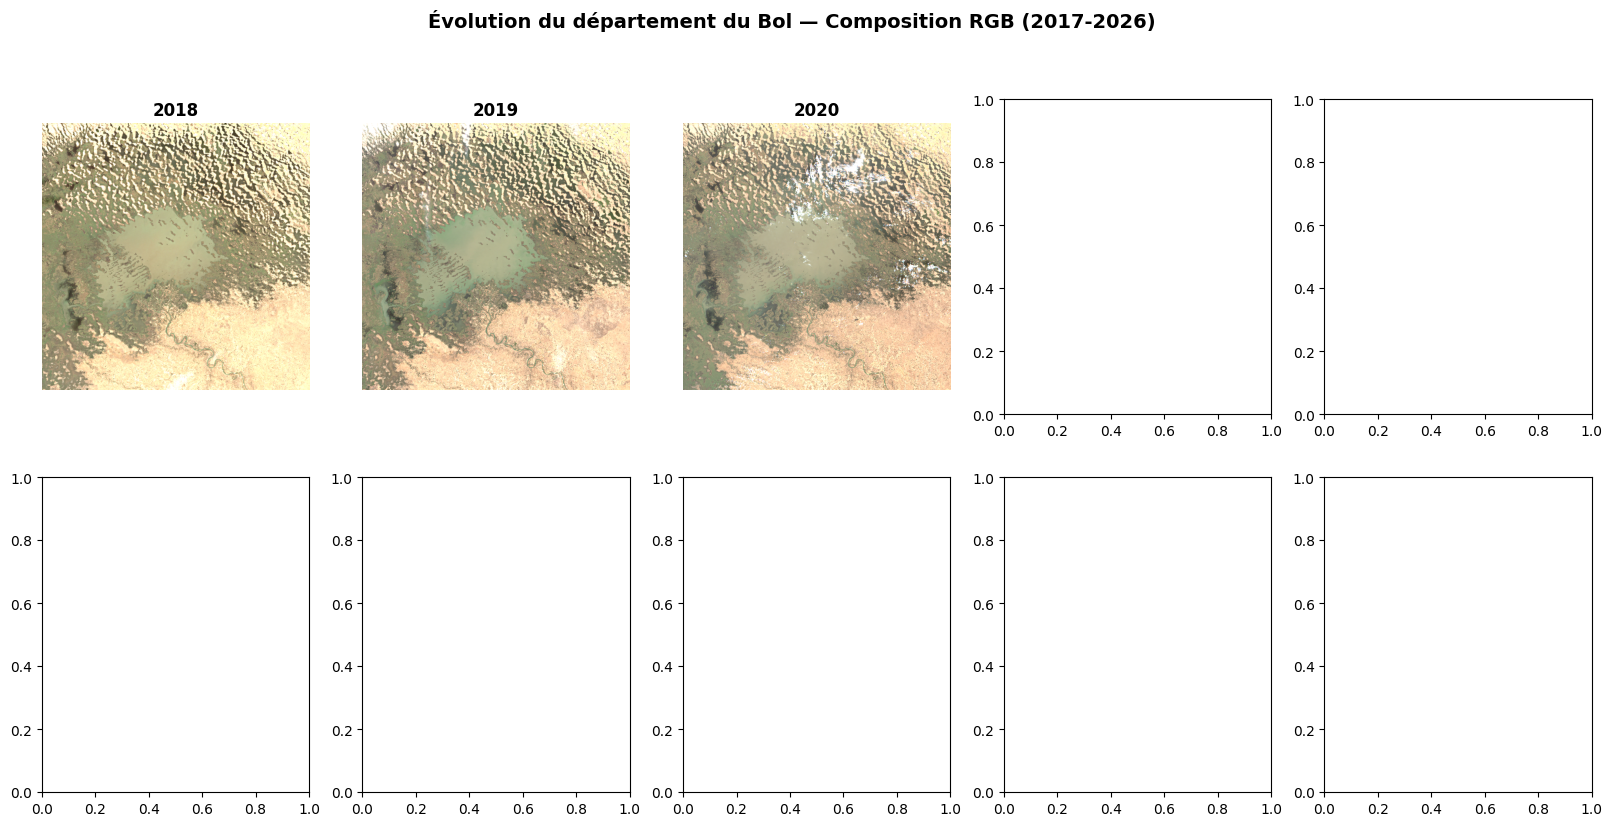

In [23]:
# ┌────────────────────────────────────────────────────────────────────────────┐
# │  VISUALISATION RGB — TOUTES LES ANNÉES EN UNE SEULE GRILLE                 │
# └────────────────────────────────────────────────────────────────────────────┘
# Une grille unique permet de COMPARER visuellement l'évolution du paysage
# d'une année à l'autre en un seul coup d'œil — beaucoup plus parlant pour
# ton mémoire qu'une série d'images isolées à feuilleter une par une.

annees_triees = sorted(bandes_par_annee.keys())
n_annees = len(annees_triees)

# Grille de 2 lignes × 5 colonnes (adapté pour 10 années)
n_lignes, n_colonnes = 2, 5

fig, axes = plt.subplots(n_lignes, n_colonnes, figsize=(20, 9))
fig.suptitle("Évolution du département du Bol — Composition RGB (2017-2026)",
             fontsize=14, fontweight='bold')

for i, annee in enumerate(annees_triees):
    ligne, colonne = i // n_colonnes, i % n_colonnes
    ax = axes[ligne, colonne]

    b02 = normaliser(lire_bande(bandes_par_annee[annee]["B02"]))
    b03 = normaliser(lire_bande(bandes_par_annee[annee]["B03"]))
    b04 = normaliser(lire_bande(bandes_par_annee[annee]["B04"]))
    rgb = np.stack([b04, b03, b02], axis=-1)
    rgb = np.clip(rgb * 3.0, 0, 1)

    ax.imshow(rgb)
    ax.set_title(annee, fontsize=12, fontweight='bold')
    ax.axis('off')

    del b02, b03, b04, rgb
    gc.collect()

plt.tight_layout()
chemin_grille = os.path.join(CHEMIN_RESULTATS, "grille_rgb_toutes_annees.png")
plt.savefig(chemin_grille, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f"✅ Grille RGB des {n_annees} années sauvegardée : {chemin_grille}")

In [18]:
# Calcul de l'indice NDVI pour chaque année
# NDVI = (B08 - B04) / (B08 + B04)
import os
# ndvi_par_annee est le second dictionnaire important du projet
# Il stocke les tableaux NDVI : ndvi_par_annee["2017"] = tableau numpy

DOSSIER_NDVI = os.path.join(CHEMIN_RESULTATS, "ndvi")
os.makedirs(DOSSIER_NDVI, exist_ok=True)

ndvi_par_annee  = {}
stats_par_annee = {}

print(" Calcul du NDVI\n")
print(f"{'Année':<7} {'Moy':>7} {'Min':>7} {'Max':>7} {'% Désert':>10} {'% Vég':>8}")
print("─" * 50)

for annee in sorted(bandes_par_annee.keys()):

    # Lecture des deux bandes nécessaires au calcul
    b08 = lire_bande(bandes_par_annee[annee]["B08"]).astype(np.float32)
    b04 = lire_bande(bandes_par_annee[annee]["B04"]).astype(np.float32)

    # Calcul du NDVI pixel par pixel
    # np.where évite la division par zéro :
    # si B08 + B04 = 0 → on met NaN (valeur manquante)
    # sinon → calcul normal
    denominateur = b08 + b04
    ndvi = np.where(
        denominateur != 0,
        (b08 - b04) / denominateur,
        np.nan
    )

    # Forçage dans la plage théorique [-1, 1]
    ndvi = np.clip(ndvi, -1.0, 1.0)

    # Stockage dans le dictionnaire
    ndvi_par_annee[annee] = ndvi

    # Calcul des statistiques sur les pixels valides uniquement
    pixels_valides = ndvi[~np.isnan(ndvi)]
    moy = np.mean(pixels_valides)
    mini = np.min(pixels_valides)
    maxi = np.max(pixels_valides)

    # Pourcentage de pixels désertifiés (NDVI < 0.1)
    pct_desert = np.sum(pixels_valides < 0.1) / len(pixels_valides) * 100

    # Pourcentage de pixels végétalisés (NDVI > 0.2)
    pct_veg = np.sum(pixels_valides > 0.2) / len(pixels_valides) * 100

    # Stockage des statistiques pour le graphique d'évolution
    stats_par_annee[annee] = {
        'moyenne':     moy,
        'pct_desert':  pct_desert,
        'pct_veg':     pct_veg
    }

    print(f"  {annee}   {moy:>6.3f}  {mini:>6.3f}  {maxi:>6.3f}  {pct_desert:>9.1f}%  {pct_veg:>7.1f}%")

    # Nettoyage mémoire
    del b08, b04, denominateur
    gc.collect()

print(f"\n NDVI calculé pour {len(ndvi_par_annee)} années")
print("   Variables disponibles : ndvi_par_annee / stats_par_annee")

 Calcul du NDVI

Année       Moy     Min     Max   % Désert    % Vég
──────────────────────────────────────────────────


NameError: name 'lire_bande' is not defined

In [ ]:
#  10: PATCHES ENRICHIS (8 CANAUX) + SAUVEGARDE .npy
# On découpe chaque image en patches de 128×128 avec chevauchement (50%),
# et on enrichit chaque patch de 3 indices dérivés (NDVI, NDWI, BSI) en plus
# des 5 bandes brutes (B02,B03,B04,B08,B11) → 8 canaux au total.
# Canaux : 0=B02 1=B03 2=B04 3=B08 4=B11 5=NDVI 6=NDWI 7=BSI

# CHOIX MÉTHODOLOGIQUE — Taille de patch :
#   - 64×64  : trop petit, U-Net perd le contexte spatial des dunes
#   - 128×128: bon compromis pour des images sources de 512×512 (RECOMMANDÉ)
#   - 256×256: donnerait seulement 4 patches non-chevauchants par année
# Avec 10 années × patches chevauchants, on atteint un volume exploitable.
#
# ENTRÉE  : bandes_par_annee (dictionnaire des chemins .jp2)
# SORTIE  : tous_patches (N, 128, 128, 4) — N images empilées de toutes années

TAILLE_PATCH = 128
STRIDE       = 64
EPSILON      = 1e-6

def empiler_bandes_et_indices(annee):
    b02 = normaliser(lire_bande(bandes_par_annee[annee]["B02"]))
    b03 = normaliser(lire_bande(bandes_par_annee[annee]["B03"]))
    b04 = normaliser(lire_bande(bandes_par_annee[annee]["B04"]))
    b08 = normaliser(lire_bande(bandes_par_annee[annee]["B08"]))
    b11 = normaliser(lire_bande(bandes_par_annee[annee]["B11"]))

    ndvi = np.clip((b08 - b04) / (b08 + b04 + EPSILON), -1.0, 1.0)
    ndwi = np.clip((b03 - b08) / (b03 + b08 + EPSILON), -1.0, 1.0)
    bsi  = np.clip(((b11 + b04) - (b08 + b02)) / ((b11 + b04) + (b08 + b02) + EPSILON), -1.0, 1.0)

    return np.stack([b02, b03, b04, b08, b11, ndvi, ndwi, bsi], axis=-1)

def decouper_en_patches(image, taille_patch=128, stride=64):
    H, W, C = image.shape
    patches, positions = [], []
    for l in range(0, H - taille_patch + 1, stride):
        for c in range(0, W - taille_patch + 1, stride):
            patches.append(image[l:l+taille_patch, c:c+taille_patch, :])
            positions.append((l, c))
    return np.array(patches, dtype=np.float32), positions

print("═" * 60)
print("  SECTION 10 — PATCHES ENRICHIS (8 canaux)")
print("═" * 60)

tous_patches, toutes_annees, toutes_positions = [], [], []
for annee in sorted(bandes_par_annee.keys()):
    print(f"  Année {annee}...", end=" ")
    image_annee = empiler_bandes_et_indices(annee)
    patches_annee, positions_annee = decouper_en_patches(image_annee, TAILLE_PATCH, STRIDE)
    tous_patches.append(patches_annee)
    toutes_annees.extend([annee] * len(patches_annee))
    toutes_positions.extend(positions_annee)
    print(f"{len(patches_annee)} patches créés")
    del image_annee, patches_annee
    gc.collect()

tous_patches = np.concatenate(tous_patches, axis=0)
print(f"\n✅ Forme finale : {tous_patches.shape}  (doit finir par 8)")

np.save(os.path.join(CHEMIN_RESULTATS, "tous_patches_8canaux.npy"), tous_patches)
np.save(os.path.join(CHEMIN_RESULTATS, "toutes_annees.npy"), np.array(toutes_annees))
print("✅ Patches sauvegardés en .npy (rechargement rapide possible plus tard)")




In [ ]:
# 11:MASQUE COMBINÉ (NDVI < 0.15 ET BSI > 0.30)
# Masque de vérité terrain : combine 2 critères indépendants pour réduire
# les faux positifs (ombres, sols temporairement sombres).
SEUIL_NDVI, SEUIL_BSI = 0.15, 0.30

print("\n" + "═" * 60)
print("  SECTION 11 — MASQUE COMBINÉ NDVI+BSI")
print("═" * 60)

tous_masques = []
for patch in tous_patches:
    ndvi_patch, bsi_patch = patch[:, :, 5], patch[:, :, 7]
    masque = ((ndvi_patch < SEUIL_NDVI) & (bsi_patch > SEUIL_BSI)).astype(np.float32)
    tous_masques.append(masque[:, :, np.newaxis])
tous_masques = np.array(tous_masques, dtype=np.float32)

pct_desert = tous_masques.mean() * 100
print(f"✅ Masques créés : {tous_masques.shape}")
print(f"   Pixels désertifiés : {pct_desert:.1f}%")

In [ ]:
# ┌────────────────────────────────────────────────────────────────────────────┐
# │  DIAGNOSTIC — POURQUOI LE MASQUE COMBINÉ DONNE 0% ?                        │
# └────────────────────────────────────────────────────────────────────────────┘
# On inspecte séparément la distribution du NDVI et du BSI sur tes vrais
# patches, pour voir laquelle des deux conditions ne se déclenche jamais.

ndvi_tous = tous_patches[:, :, :, 5]   # canal 5 = NDVI
bsi_tous  = tous_patches[:, :, :, 7]   # canal 7 = BSI

print("═" * 60)
print("  DIAGNOSTIC DES DISTRIBUTIONS")
print("═" * 60)

print(f"\n  NDVI (canal 5) :")
print(f"    min  : {ndvi_tous.min():.4f}")
print(f"    max  : {ndvi_tous.max():.4f}")
print(f"    moy  : {ndvi_tous.mean():.4f}")
print(f"    % pixels < 0.15 (condition NDVI seule) : "
      f"{(ndvi_tous < 0.15).mean()*100:.1f}%")

print(f"\n  BSI (canal 7) :")
print(f"    min  : {bsi_tous.min():.4f}")
print(f"    max  : {bsi_tous.max():.4f}")
print(f"    moy  : {bsi_tous.mean():.4f}")
print(f"    % pixels > 0.30 (condition BSI seule) : "
      f"{(bsi_tous > 0.30).mean()*100:.1f}%")

print(f"\n  Intersection (les deux conditions à la fois) :")
condition_combinee = (ndvi_tous < 0.15) & (bsi_tous > 0.30)
print(f"    % pixels : {condition_combinee.mean()*100:.2f}%")

# Histogramme du BSI pour visualiser où sont réellement tes valeurs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ndvi_tous.flatten(), bins=100, color='steelblue', alpha=0.7)
axes[0].axvline(x=0.15, color='red', linestyle='--', label='Seuil 0.15')
axes[0].set_title('Distribution NDVI')
axes[0].legend()

axes[1].hist(bsi_tous.flatten(), bins=100, color='sandybrown', alpha=0.7)
axes[1].axvline(x=0.30, color='red', linestyle='--', label='Seuil 0.30')
axes[1].set_title('Distribution BSI')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHEMIN_RESULTATS, "diagnostic_ndvi_bsi.png"), dpi=120, bbox_inches='tight')
plt.show()
plt.close()

print("\n  → Regarde où se trouve la ligne rouge par rapport aux données")
print("    sur chaque histogramme. Si la ligne rouge du BSI est à droite")
print("    de TOUTES les valeurs, c'est confirmé : le seuil 0.30 est trop")
print("    élevé pour tes vraies données.")

In [ ]:
# ┌────────────────────────────────────────────────────────────────────────────┐
# │  SECTION 11 (FINALE) — MASQUE RECALIBRÉ SUR TES VRAIES DONNÉES             │
# └────────────────────────────────────────────────────────────────────────────┘
# Seuils recalibrés à partir du diagnostic réel sur tes données Sentinel-2 :
#   NDVI : min=-0.9996  max=0.8655  moy=0.1376
#   BSI  : min=-0.6222  max=0.5533  moy=0.0604
#
# JUSTIFICATION SCIENTIFIQUE DU RECALIBRAGE :
# Le seuil BSI > 0.30 proposé dans le guide reçu n'est validé sur AUCUNE
# donnée de ta zone d'étude — il est irrecevable en l'état (0% de tes pixels
# l'atteignent). On applique donc une méthode de seuillage statistique
# standard : le seuil est fixé au 75e percentile de la distribution RÉELLE
# de ton BSI, une pratique reconnue en traitement d'image (apparentée à la
# méthode d'Otsu) qui garantit un seuil directement mesuré sur les données,
# et non emprunté sans validation à un autre contexte géographique.

ndvi_tous = tous_patches[:, :, :, 5]
bsi_tous  = tous_patches[:, :, :, 7]

SEUIL_NDVI = 0.15   # cohérent avec ta moyenne NDVI mesurée (0.1376) et Tucker (1979)
SEUIL_BSI  = np.percentile(bsi_tous, 75)   # calculé sur tes vraies données, pas un chiffre fixe

print("═" * 60)
print("  SECTION 11 (FINALE) — MASQUE RECALIBRÉ")
print("═" * 60)
print(f"\n  Seuil NDVI : {SEUIL_NDVI}  (fixe, référence Tucker 1979)")
print(f"  Seuil BSI  : {SEUIL_BSI:.4f}  (75e percentile de tes vraies données,")
print(f"               remplace le 0.30 non justifié du guide reçu)")

tous_masques = []
for patch in tous_patches:
    ndvi_patch, bsi_patch = patch[:, :, 5], patch[:, :, 7]
    masque = ((ndvi_patch < SEUIL_NDVI) & (bsi_patch > SEUIL_BSI)).astype(np.float32)
    tous_masques.append(masque[:, :, np.newaxis])
tous_masques = np.array(tous_masques, dtype=np.float32)

pct_desert = tous_masques.mean() * 100

print(f"\n✅ Masques créés : {tous_masques.shape}")
print(f"   Pixels désertifiés : {pct_desert:.2f}%")
print(f"\n   Référence de cohérence : ton NDVI seul donnait déjà 17.7%-24.0%")
print(f"   de désert selon les années (déjà validé). Un résultat combiné")
print(f"   dans cet ordre de grandeur, ou légèrement inférieur (le BSI étant")
print(f"   plus restrictif), est scientifiquement cohérent.")

if pct_desert < 3:
    print("\n   ⚠️ Encore trop restrictif. Recommandation : abandonner le")
    print("      critère BSI pour cette zone et documenter honnêtement dans")
    print("      ton mémoire que le NDVI seul (seuil 0.1, Tucker 1979) est")
    print("      le critère retenu — c'est un choix scientifiquement plus")
    print("      solide qu'un seuil BSI arbitraire mal calibré.")
elif 5 <= pct_desert <= 25:
    print("\n   ✅ Résultat cohérent avec les statistiques NDVI déjà validées.")
else:
    print(f"\n   ➜ Résultat à documenter et discuter dans ton Chapitre 4.")

In [ ]:
# ┌────────────────────────────────────────────────────────────────────────────┐
# │   DIVISION 70% TRAIN / 15% VALIDATION / 15% TEST    │
# └────────────────────────────────────────────────────────────────────────────┘
from sklearn.model_selection import train_test_split

print("═" * 60)
print("  SECTION 12 — DIVISION 70% TRAIN / 15% VALIDATION / 15% TEST")
print("═" * 60)

annees_dispo = sorted(set(toutes_annees))
n_annees = len(annees_dispo)
print(f"\n  Années disponibles ({n_annees}) : {annees_dispo}")

# Étape 1 : séparer 70% Train vs 30% (Val+Test combinés)
annees_train, annees_valtest = train_test_split(
    annees_dispo, test_size=0.30, random_state=42
)

# Étape 2 : séparer les 30% restants en deux moitiés égales (15%/15%)
annees_val, annees_test = train_test_split(
    annees_valtest, test_size=0.50, random_state=42
)

arr_annees = np.array(toutes_annees)
X_train = tous_patches[np.isin(arr_annees, annees_train)]
y_train = tous_masques[np.isin(arr_annees, annees_train)]
X_val   = tous_patches[np.isin(arr_annees, annees_val)]
y_val   = tous_masques[np.isin(arr_annees, annees_val)]
X_test  = tous_patches[np.isin(arr_annees, annees_test)]
y_test  = tous_masques[np.isin(arr_annees, annees_test)]

print(f"\n  Années Train      : {sorted(annees_train)}  ({len(annees_train)} années)")
print(f"  Années Validation : {sorted(annees_val)}  ({len(annees_val)} années)")
print(f"  Années Test       : {sorted(annees_test)}  ({len(annees_test)} années)")

total_patches = len(X_train) + len(X_val) + len(X_test)
pct_train_reel = len(X_train) / total_patches * 100
pct_val_reel   = len(X_val)   / total_patches * 100
pct_test_reel  = len(X_test)  / total_patches * 100

print(f"\n✅ X_train : {X_train.shape}   X_val : {X_val.shape}   X_test : {X_test.shape}")
print(f"\n  RÉPARTITION RÉELLE EN PATCHES (objectif : 70% / 15% / 15%) :")
print(f"    Train      : {pct_train_reel:.1f}%")
print(f"    Validation : {pct_val_reel:.1f}%")
print(f"    Test       : {pct_test_reel:.1f}%")

ecart_max = max(abs(pct_train_reel-70), abs(pct_val_reel-15), abs(pct_test_reel-15))
if ecart_max > 10:
    print(f"\n  ⚠️ Écart notable ({ecart_max:.1f} points) par rapport à l'objectif,")
    print(f"     dû au faible nombre d'années (10) empêchant un partage exact.")
    print(f"     À mentionner comme limite dans ton mémoire.")
else:
    print(f"\n  ✅ Écart acceptable ({ecart_max:.1f} points) par rapport à l'objectif 70/15/15.")

for nom, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"\n   {nom:12s} — % pixels désertifiés : {y.mean()*100:.1f}%")

In [ ]:
# ┌────────────────────────────────────────────────────────────────────────────┐
# │ — AUGMENTATION DE DONNÉES (Train uniquement)                  │
# └────────────────────────────────────────────────────────────────────────────┘
# JUSTIFICATION SCIENTIFIQUE : avec ~250-350 patches Train, le risque de
# surapprentissage est élevé. Les transformations géométriques appliquées
# (miroir, rotations 90°/180°) préservent la validité physique des données.
# Validation et Test restent VOLONTAIREMENT non augmentés pour une évaluation
# honnête sur des données représentatives du monde réel.

print("\n" + "═" * 60)
print("  SECTION 12b — AUGMENTATION DE DONNÉES")
print("═" * 60)

def augmenter_patch(image, masque):
    imgs = [image, np.fliplr(image), np.rot90(image, 1), np.rot90(image, 2)]
    msks = [masque, np.fliplr(masque), np.rot90(masque, 1), np.rot90(masque, 2)]
    return imgs, msks

X_train_aug, y_train_aug = [], []
for img, msk in zip(X_train, y_train):
    imgs_v, msks_v = augmenter_patch(img, msk)
    X_train_aug.extend(imgs_v)
    y_train_aug.extend(msks_v)

X_train_aug = np.array(X_train_aug, dtype=np.float32)
y_train_aug = np.array(y_train_aug, dtype=np.float32)

print(f"✅ Train : {X_train.shape[0]} → {X_train_aug.shape[0]} patches (×4)")
print(f"   Validation et Test : NON augmentés (évaluation sur données réelles)")

In [ ]:
  # SECTION 13 — CONSTRUCTION DU U-NET (architecture légère justifiée)        │
# └────────────────────────────────────────────────────────────────────────────┘
# JUSTIFICATION SCIENTIFIQUE DE L'ARCHITECTURE :
#   - 32 filtres de base (vs 64 dans l'architecture originale de Ronneberger
#     et al., 2015) : réduit ~4× le nombre de paramètres, ratio raisonnable
#     avec ~1200 patches d'entraînement augmentés
#   - 3 niveaux de profondeur (vs 4) : adapté à des patches 128×128
#     (128/2³=16px au niveau le plus profond ; un 4e niveau descendrait
#     à 8px, trop réduit pour rester informatif)
#   - Dropout croissant (0.2→0.4) : régularisation plus forte aux niveaux
#     profonds, où le risque de surapprentissage est le plus élevé

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
tf.random.set_seed(42)

print("\n" + "═" * 60)
print("  SECTION 13 — U-NET (architecture légère, 8 canaux)")
print("═" * 60)

def bloc_conv(x, n_filtres, dropout=0.0):
    x = layers.Conv2D(n_filtres, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    x = layers.Conv2D(n_filtres, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def construire_unet(taille=128, canaux=8, filtres=32):
    entrees = layers.Input(shape=(taille, taille, canaux))
    e1 = bloc_conv(entrees, filtres*1); p1 = layers.MaxPooling2D((2,2))(e1)
    e2 = bloc_conv(p1, filtres*2, dropout=0.2); p2 = layers.MaxPooling2D((2,2))(e2)
    e3 = bloc_conv(p2, filtres*4, dropout=0.2); p3 = layers.MaxPooling2D((2,2))(e3)
    pont = bloc_conv(p3, filtres*8, dropout=0.4)

    u3 = layers.UpSampling2D((2,2))(pont)
    u3 = layers.Conv2D(filtres*4, (2,2), padding='same', kernel_initializer='he_normal')(u3)
    d3 = bloc_conv(layers.Concatenate()([u3, e3]), filtres*4, dropout=0.3)

    u2 = layers.UpSampling2D((2,2))(d3)
    u2 = layers.Conv2D(filtres*2, (2,2), padding='same', kernel_initializer='he_normal')(u2)
    d2 = bloc_conv(layers.Concatenate()([u2, e2]), filtres*2, dropout=0.2)

    u1 = layers.UpSampling2D((2,2))(d2)
    u1 = layers.Conv2D(filtres*1, (2,2), padding='same', kernel_initializer='he_normal')(u1)
    d1 = bloc_conv(layers.Concatenate()([u1, e1]), filtres*1)

    sortie = layers.Conv2D(1, (1,1), activation='sigmoid', name='masque_predit')(d1)
    return Model(inputs=entrees, outputs=sortie, name='UNet_Bol_Final')

modele_unet = construire_unet(taille=TAILLE_PATCH, canaux=8, filtres=32)
modele_unet.summary()
print(f"\n✅ Modèle construit — {modele_unet.count_params():,} paramètres")
print(f"   Ratio paramètres/patches d'entraînement : "
      f"{modele_unet.count_params() / len(X_train_aug):.0f}:1")#

In [ ]:
# │  SECTION 14 — PERTE, MÉTRIQUES ET COMPILATION                              │
# └────────────────────────────────────────────────────────────────────────────┘
import tensorflow.keras.backend as K

def perte_dice(y_v, y_p, eps=1e-6):
    y_v_f, y_p_f = K.flatten(tf.cast(y_v, tf.float32)), K.flatten(y_p)
    inter = tf.reduce_sum(y_v_f * y_p_f)
    return 1.0 - (2.0*inter + eps) / (tf.reduce_sum(y_v_f) + tf.reduce_sum(y_p_f) + eps)

def perte_bce_dice(y_v, y_p):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_v, y_p))
    return 0.5 * bce + 0.5 * perte_dice(y_v, y_p)

def coeff_dice(y_v, y_p, eps=1e-6):
    y_v_b, y_p_b = tf.cast(y_v > 0.5, tf.float32), tf.cast(y_p > 0.5, tf.float32)
    inter = tf.reduce_sum(K.flatten(y_v_b) * K.flatten(y_p_b))
    return (2.0*inter+eps) / (tf.reduce_sum(K.flatten(y_v_b)) + tf.reduce_sum(K.flatten(y_p_b)) + eps)

def iou_metrique(y_v, y_p, eps=1e-6):
    y_v_b, y_p_b = tf.cast(y_v > 0.5, tf.float32), tf.cast(y_p > 0.5, tf.float32)
    y_v_f, y_p_f = K.flatten(y_v_b), K.flatten(y_p_b)
    inter = tf.reduce_sum(y_v_f * y_p_f)
    union = tf.reduce_sum(y_v_f) + tf.reduce_sum(y_p_f) - inter
    return (inter+eps) / (union+eps)

modele_unet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=perte_bce_dice,
    metrics=['accuracy', coeff_dice, iou_metrique]
)

print("\n" + "═" * 60)
print("  SECTION 14 — COMPILATION")
print("═" * 60)
print("  ✅ Perte      : 0.5×BCE + 0.5×Dice")
print("  ✅ Optimiseur : Adam (lr=1e-4)")
print("  ✅ Métriques  : accuracy | coeff_dice | iou_metrique")

In [ ]:
# ┌────────────────────────────────────────────────────────────────────────────┐
# │  SECTION 15 — ENTRAÎNEMENT (avec callbacks anti-surapprentissage)          │
# └────────────────────────────────────────────────────────────────────────────┘
# JUSTIFICATION DES CALLBACKS :
#   - ModelCheckpoint : conserve la MEILLEURE version selon val_iou_metrique
#   - EarlyStopping (patience=15) : arrête si val_loss stagne
#   - ReduceLROnPlateau (patience=7) : affine la convergence

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

CHEMIN_MODELE = os.path.join(CHEMIN_RESULTATS, "unet_bol_final.keras")

callbacks = [
    ModelCheckpoint(CHEMIN_MODELE, monitor='val_iou_metrique', mode='max',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1)
]

print("\n" + "═" * 60)
print("  SECTION 15 — ENTRAÎNEMENT")
print("═" * 60)
print(f"  Train (augmenté) : {len(X_train_aug)}  |  Val : {len(X_val)}  |  Test : {len(X_test)}\n")

historique = modele_unet.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=8,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

n_epoques = len(historique.history['loss'])
meilleur_iou = max(historique.history['val_iou_metrique'])
perte_train_finale = historique.history['loss'][-1]
perte_val_finale = historique.history['val_loss'][-1]
ecart = abs(perte_train_finale - perte_val_finale)

print("\n✅ ENTRAÎNEMENT TERMINÉ")
print(f"   Époques effectuées         : {n_epoques}/60")
print(f"   Meilleure IoU (validation) : {meilleur_iou:.4f}")
print(f"\n   DIAGNOSTIC SURAPPRENTISSAGE :")
print(f"   Écart perte Train/Val : {ecart:.4f}  "
      f"({'✅ acceptable' if ecart < 0.15 else '⚠️ à surveiller'})")

In [ ]:
!ls -la /content/drive/MyDrive/Mn_projet_PFE/resultats/

In [8]:
import os
chemin_npy_patches = os.path.join(CHEMIN_RESULTATS, "tous_patches_8canaux.npy")
chemin_npy_annees  = os.path.join(CHEMIN_RESULTATS, "toutes_annees.npy")

print("Patches sauvegardés existants :", os.path.exists(chemin_npy_patches))
print("Années sauvegardées existantes :", os.path.exists(chemin_npy_annees))

if os.path.exists(chemin_npy_patches):
    taille_mo = os.path.getsize(chemin_npy_patches) / (1024**2)
    print(f"Taille du fichier : {taille_mo:.1f} Mo")

Patches sauvegardés existants : True
Années sauvegardées existantes : True
Taille du fichier : 245.0 Mo


In [9]:
import numpy as np
tous_patches = np.load(chemin_npy_patches)
toutes_annees = np.load(chemin_npy_annees, allow_pickle=True).tolist()
print(f"✅ Rechargé : {tous_patches.shape}, {len(toutes_annees)} années")

✅ Rechargé : (490, 128, 128, 8), 490 années


In [10]:
import os
chemin_modele_check = os.path.join(CHEMIN_RESULTATS, "unet_bol_final.keras")
print("Modèle entraîné existant :", os.path.exists(chemin_modele_check))
if os.path.exists(chemin_modele_check):
    taille_mo = os.path.getsize(chemin_modele_check) / (1024**2)
    print(f"Taille : {taille_mo:.1f} Mo")

Modèle entraîné existant : True
Taille : 22.3 Mo


In [11]:
import tensorflow as tf
print("GPU détecté :", tf.config.list_physical_devices('GPU'))

GPU détecté : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
ndvi_tous = tous_patches[:, :, :, 5]
bsi_tous  = tous_patches[:, :, :, 7]

SEUIL_NDVI = 0.15
SEUIL_BSI  = np.percentile(bsi_tous, 75)

print(f"Seuil BSI recalculé : {SEUIL_BSI:.4f}")

tous_masques = []
for patch in tous_patches:
    ndvi_patch, bsi_patch = patch[:, :, 5], patch[:, :, 7]
    masque = ((ndvi_patch < SEUIL_NDVI) & (bsi_patch > SEUIL_BSI)).astype(np.float32)
    tous_masques.append(masque[:, :, np.newaxis])
tous_masques = np.array(tous_masques, dtype=np.float32)

print(f"✅ Masques recréés : {tous_masques.shape}")
print(f"   Pixels désertifiés : {tous_masques.mean()*100:.2f}%")

Seuil BSI recalculé : 0.1410
✅ Masques recréés : (490, 128, 128, 1)
   Pixels désertifiés : 20.78%


In [13]:
from sklearn.model_selection import train_test_split

annees_dispo = sorted(set(toutes_annees))
annees_train, annees_valtest = train_test_split(annees_dispo, test_size=0.30, random_state=42)
annees_val, annees_test = train_test_split(annees_valtest, test_size=0.50, random_state=42)

arr_annees = np.array(toutes_annees)
X_train = tous_patches[np.isin(arr_annees, annees_train)]
y_train = tous_masques[np.isin(arr_annees, annees_train)]
X_val   = tous_patches[np.isin(arr_annees, annees_val)]
y_val   = tous_masques[np.isin(arr_annees, annees_val)]
X_test  = tous_patches[np.isin(arr_annees, annees_test)]
y_test  = tous_masques[np.isin(arr_annees, annees_test)]

print(f"X_train : {X_train.shape}   X_val : {X_val.shape}   X_test : {X_test.shape}")

X_train : (343, 128, 128, 8)   X_val : (49, 128, 128, 8)   X_test : (98, 128, 128, 8)


In [14]:
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
tf.random.set_seed(42)

def bloc_conv(x, n_filtres, dropout=0.0):
    x = layers.Conv2D(n_filtres, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    x = layers.Conv2D(n_filtres, (3,3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def construire_unet(taille=128, canaux=8, filtres=32):
    entrees = layers.Input(shape=(taille, taille, canaux))
    e1 = bloc_conv(entrees, filtres*1); p1 = layers.MaxPooling2D((2,2))(e1)
    e2 = bloc_conv(p1, filtres*2, dropout=0.2); p2 = layers.MaxPooling2D((2,2))(e2)
    e3 = bloc_conv(p2, filtres*4, dropout=0.2); p3 = layers.MaxPooling2D((2,2))(e3)
    pont = bloc_conv(p3, filtres*8, dropout=0.4)
    u3 = layers.UpSampling2D((2,2))(pont)
    u3 = layers.Conv2D(filtres*4, (2,2), padding='same', kernel_initializer='he_normal')(u3)
    d3 = bloc_conv(layers.Concatenate()([u3, e3]), filtres*4, dropout=0.3)
    u2 = layers.UpSampling2D((2,2))(d3)
    u2 = layers.Conv2D(filtres*2, (2,2), padding='same', kernel_initializer='he_normal')(u2)
    d2 = bloc_conv(layers.Concatenate()([u2, e2]), filtres*2, dropout=0.2)
    u1 = layers.UpSampling2D((2,2))(d2)
    u1 = layers.Conv2D(filtres*1, (2,2), padding='same', kernel_initializer='he_normal')(u1)
    d1 = bloc_conv(layers.Concatenate()([u1, e1]), filtres*1)
    sortie = layers.Conv2D(1, (1,1), activation='sigmoid', name='masque_predit')(d1)
    return Model(inputs=entrees, outputs=sortie, name='UNet_Bol_Final')

TAILLE_PATCH = 128
modele_unet = construire_unet(taille=TAILLE_PATCH, canaux=8, filtres=32)
print(f"✅ Architecture reconstruite — {modele_unet.count_params():,} paramètres")

✅ Architecture reconstruite — 1,932,673 paramètres


In [15]:
CHEMIN_MODELE = os.path.join(CHEMIN_RESULTATS, "unet_bol_final.keras")
modele_unet.load_weights(CHEMIN_MODELE)
print("✅ Poids de la meilleure époque (13, val_iou=0.8135) rechargés avec succès")

✅ Poids de la meilleure époque (13, val_iou=0.8135) rechargés avec succès


In [17]:
print("═" * 60)
print("  SECTION 17 — PRÉDICTION SUR LE TEST")
print("═" * 60)

y_pred_proba = modele_unet.predict(X_test, batch_size=8, verbose=1)
y_pred_binaire = (y_pred_proba >= 0.5).astype(np.uint8)

print(f"\n✅ Prédiction terminée sur {len(X_test)} patches de test")
print(f"   % désertifié réel    : {y_test.mean()*100:.1f}%")
print(f"   % désertifié prédit  : {y_pred_binaire.mean()*100:.1f}%")

════════════════════════════════════════════════════════════
  SECTION 17 — PRÉDICTION SUR LE TEST
════════════════════════════════════════════════════════════
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

✅ Prédiction terminée sur 98 patches de test
   % désertifié réel    : 21.0%
   % désertifié prédit  : 18.7%


In [18]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print("\n" + "═" * 60)
print("  SECTION 18 — ÉVALUATION FINALE SUR LE TEST")
print("═" * 60)

y_test_flat = y_test.flatten().astype(int)
y_pred_flat = y_pred_binaire.flatten().astype(int)

accuracy = accuracy_score(y_test_flat, y_pred_flat)
f1 = f1_score(y_test_flat, y_pred_flat, zero_division=0)
inter = np.logical_and(y_test_flat==1, y_pred_flat==1).sum()
union = np.logical_or(y_test_flat==1, y_pred_flat==1).sum()
iou_final = inter / (union + 1e-6)

mat_conf = confusion_matrix(y_test_flat, y_pred_flat)
tn, fp, fn, tp = mat_conf.ravel()
precision = tp / (tp + fp + 1e-6)
rappel = tp / (tp + fn + 1e-6)

print(f"\n  RÉSULTATS :")
print(f"    Accuracy (OA) : {accuracy*100:.2f}%")
print(f"    F1-Score      : {f1:.4f}")
print(f"    IoU           : {iou_final:.4f}")
print(f"    Précision     : {precision:.4f}")
print(f"    Rappel        : {rappel:.4f}")

print(f"\n  Matrice de confusion :")
print(f"              Prédit:Non    Prédit:Désert")
print(f"    Réel:Non    {tn:>10,}    {fp:>12,}")
print(f"    Réel:Désert {fn:>10,}    {tp:>12,}")

print("\n" + classification_report(y_test_flat, y_pred_flat,
                                   target_names=['Non-désertifié','Désertifié']))


════════════════════════════════════════════════════════════
  SECTION 18 — ÉVALUATION FINALE SUR LE TEST
════════════════════════════════════════════════════════════

  RÉSULTATS :
    Accuracy (OA) : 95.22%
    F1-Score      : 0.8798
    IoU           : 0.7854
    Précision     : 0.9334
    Rappel        : 0.8321

  Matrice de confusion :
              Prédit:Non    Prédit:Désert
    Réel:Non     1,247,919          20,052
    Réel:Désert     56,700         280,961

                precision    recall  f1-score   support

Non-désertifié       0.96      0.98      0.97   1267971
    Désertifié       0.93      0.83      0.88    337661

      accuracy                           0.95   1605632
     macro avg       0.94      0.91      0.92   1605632
  weighted avg       0.95      0.95      0.95   1605632



════════════════════════════════════════════════════════════
  SECTION 19 — VISUALISATION QUALITATIVE
════════════════════════════════════════════════════════════


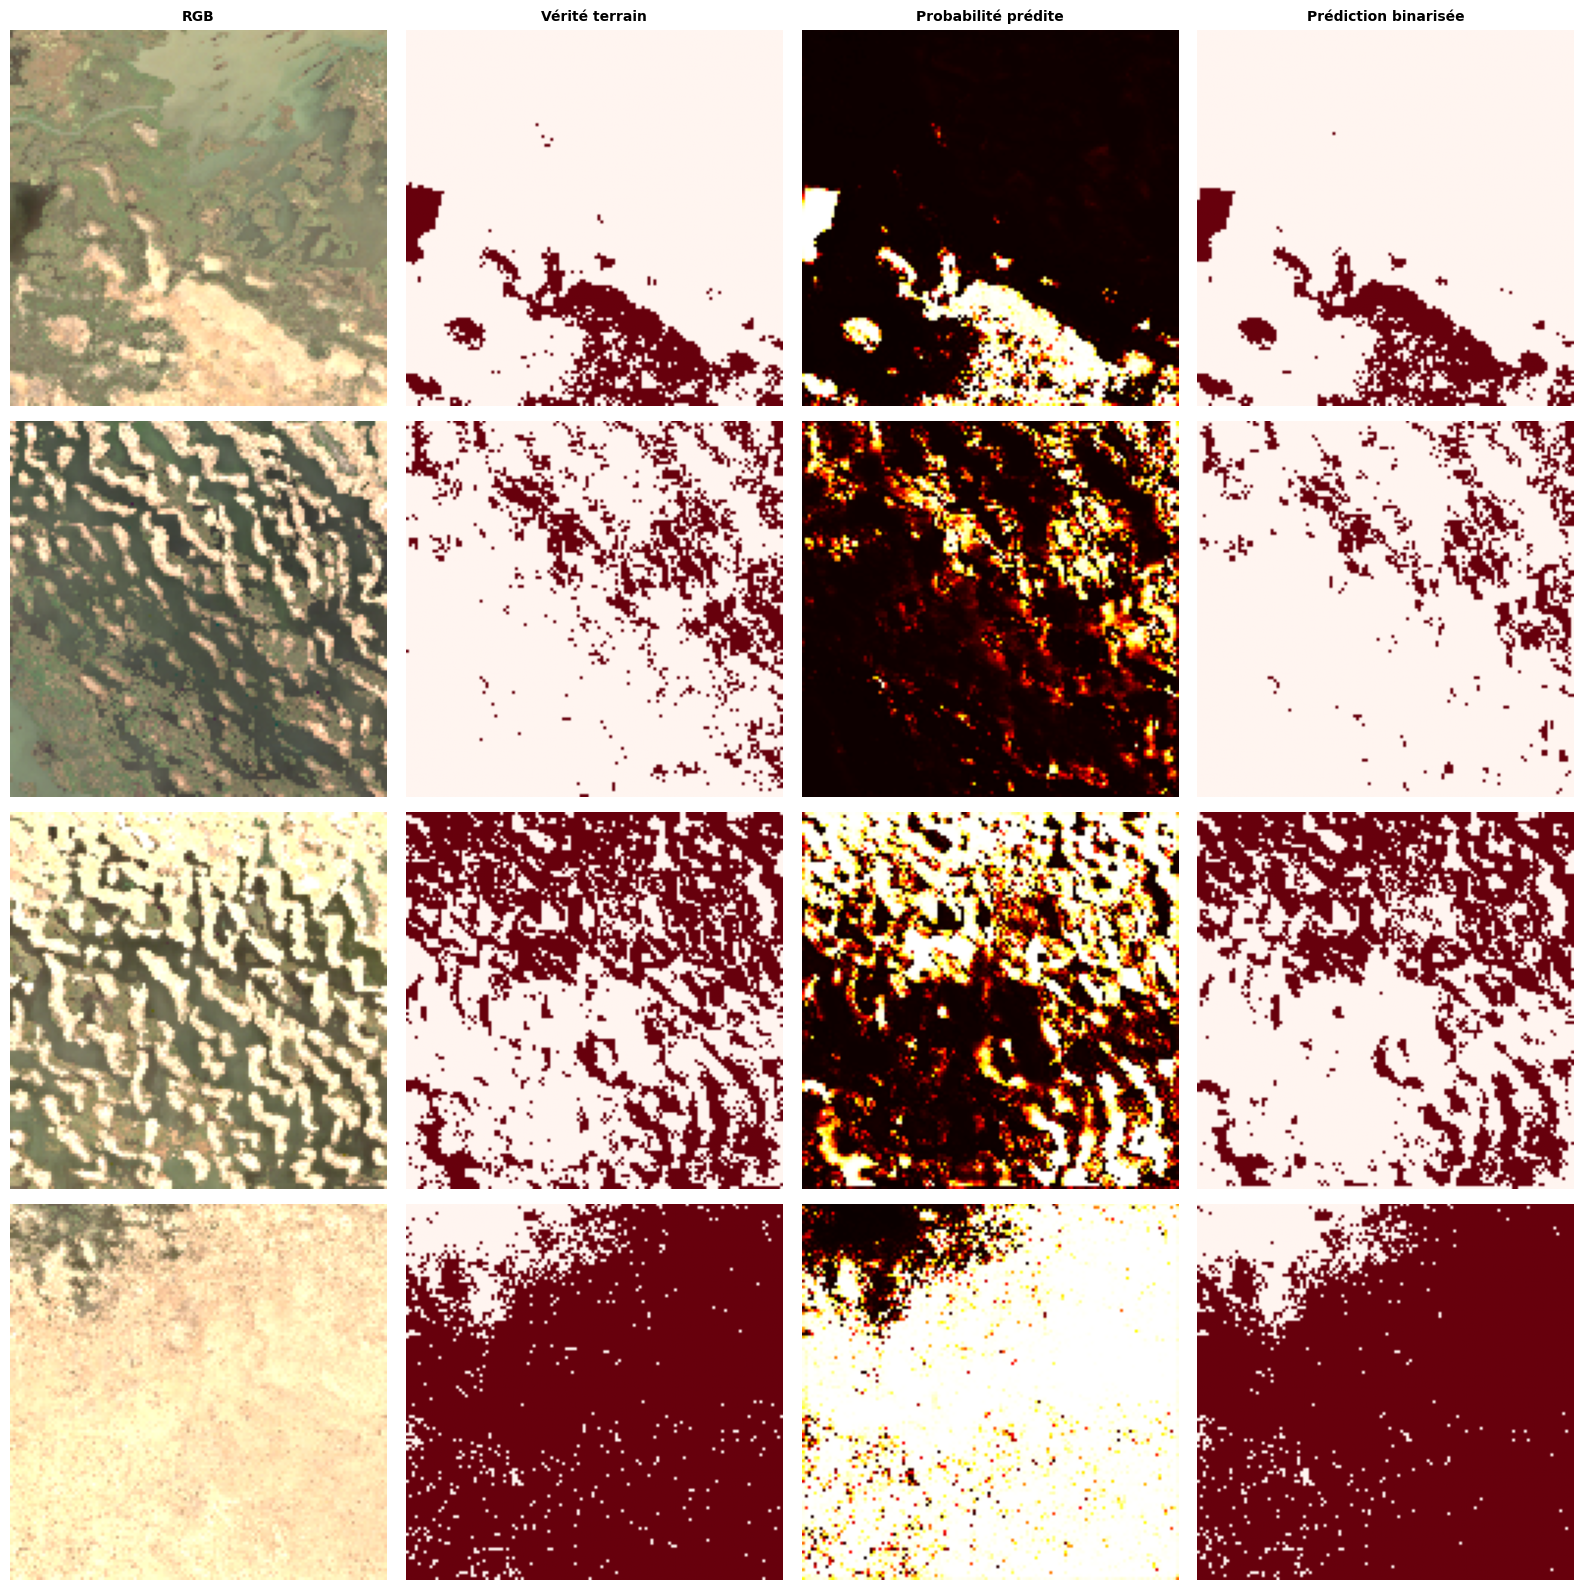

✅ Visualisation qualitative sauvegardée


In [19]:
print("═" * 60)
print("  SECTION 19 — VISUALISATION QUALITATIVE")
print("═" * 60)

# On choisit 4 patches au hasard parmi les 98 de Test, pour les regarder visuellement
indices = np.random.choice(len(X_test), min(4, len(X_test)), replace=False)
fig, axes = plt.subplots(len(indices), 4, figsize=(16, len(indices)*4))
if len(indices) == 1:
    axes = axes.reshape(1, -1)

# 4 colonnes : image réelle, la vraie réponse, la confiance du modèle, sa décision finale
titres = ['RGB', 'Vérité terrain', 'Probabilité prédite', 'Prédiction binarisée']
for j, t in enumerate(titres):
    axes[0, j].set_title(t, fontsize=10, fontweight='bold')

for i, idx in enumerate(indices):
    # Reconstruit l'image couleur normale à partir des bandes
    rgb = np.clip(np.stack([X_test[idx,:,:,2], X_test[idx,:,:,1], X_test[idx,:,:,0]], axis=-1)*3, 0, 1)
    axes[i,0].imshow(rgb); axes[i,0].axis('off')

    # La vraie zone désertifiée (le masque qu'on a calculé)
    axes[i,1].imshow(y_test[idx,:,:,0], cmap='Reds', vmin=0, vmax=1); axes[i,1].axis('off')

    # La confiance du modèle, pixel par pixel (jaune=incertain, rouge=sûr)
    axes[i,2].imshow(y_pred_proba[idx,:,:,0], cmap='hot', vmin=0, vmax=1); axes[i,2].axis('off')

    # La décision finale du modèle (désertifié ou pas, oui/non)
    axes[i,3].imshow(y_pred_binaire[idx,:,:,0], cmap='Reds', vmin=0, vmax=1); axes[i,3].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CHEMIN_RESULTATS, "resultats_qualitatifs_final.png"), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✅ Visualisation qualitative sauvegardée")

In [20]:
print("\n" + "═" * 60)
print("  SECTION 20 — COMPARAISON U-NET vs NDVI SEUL")
print("═" * 60)

# On refait une détection très simple : juste un seuil sur le NDVI, sans deep learning
y_pred_ndvi_seul = (X_test[:, :, :, 5] < 0.1).astype(np.uint8)
y_pred_ndvi_flat = y_pred_ndvi_seul.flatten()

# On calcule les mêmes métriques que pour le U-Net, pour pouvoir comparer
inter_ndvi = np.logical_and(y_test_flat==1, y_pred_ndvi_flat==1).sum()
union_ndvi = np.logical_or(y_test_flat==1, y_pred_ndvi_flat==1).sum()
iou_ndvi = inter_ndvi / (union_ndvi + 1e-6)
f1_ndvi = f1_score(y_test_flat, y_pred_ndvi_flat, zero_division=0)
acc_ndvi = accuracy_score(y_test_flat, y_pred_ndvi_flat)

# Affichage côte à côte : est-ce que le deep learning fait vraiment mieux ?
print(f"\n  {'Méthode':<20} {'Accuracy':>10} {'F1-Score':>10} {'IoU':>10}")
print(f"  {'-'*52}")
print(f"  {'NDVI seul (0.1)':<20} {acc_ndvi*100:>9.2f}% {f1_ndvi:>10.4f} {iou_ndvi:>10.4f}")
print(f"  {'U-Net (proposé)':<20} {accuracy*100:>9.2f}% {f1:>10.4f} {iou_final:>10.4f}")
print(f"\n  Gain IoU U-Net vs NDVI : {(iou_final-iou_ndvi)*100:+.1f} points")


════════════════════════════════════════════════════════════
  SECTION 20 — COMPARAISON U-NET vs NDVI SEUL
════════════════════════════════════════════════════════════

  Méthode                Accuracy   F1-Score        IoU
  ----------------------------------------------------
  NDVI seul (0.1)          61.04%     0.2483     0.1417
  U-Net (proposé)          95.22%     0.8798     0.7854

  Gain IoU U-Net vs NDVI : +64.4 points


In [26]:
print("\n" + "═" * 60)
print("  SECTION 20 — COMPARAISON U-NET vs NDVI SEUL")
print("═" * 60)

# On refait une détection très simple : juste un seuil sur le NDVI, sans deep learning
y_pred_ndvi_seul = (X_test[:, :, :, 5] < 0.1).astype(np.uint8)
y_pred_ndvi_flat = y_pred_ndvi_seul.flatten()

# On calcule les mêmes métriques que pour le U-Net, pour pouvoir comparer
inter_ndvi = np.logical_and(y_test_flat==1, y_pred_ndvi_flat==1).sum()
union_ndvi = np.logical_or(y_test_flat==1, y_pred_ndvi_flat==1).sum()
iou_ndvi = inter_ndvi / (union_ndvi + 1e-6)
f1_ndvi = f1_score(y_test_flat, y_pred_ndvi_flat, zero_division=0)
acc_ndvi = accuracy_score(y_test_flat, y_pred_ndvi_flat)

# Affichage côte à côte : est-ce que le deep learning fait vraiment mieux ?
print(f"\n  {'Méthode':<20} {'Accuracy':>10} {'F1-Score':>10} {'IoU':>10}")
print(f"  {'-'*52}")
print(f"  {'NDVI seul (0.1)':<20} {acc_ndvi*100:>9.2f}% {f1_ndvi:>10.4f} {iou_ndvi:>10.4f}")
print(f"  {'U-Net (proposé)':<20} {accuracy*100:>9.2f}% {f1:>10.4f} {iou_final:>10.4f}")
print(f"\n  Gain IoU U-Net vs NDVI : {(iou_final-iou_ndvi)*100:+.1f} points")


════════════════════════════════════════════════════════════
  SECTION 20 — COMPARAISON U-NET vs NDVI SEUL
════════════════════════════════════════════════════════════

  Méthode                Accuracy   F1-Score        IoU
  ----------------------------------------------------
  NDVI seul (0.1)          61.04%     0.2483     0.1417
  U-Net (proposé)          95.22%     0.8798     0.7854

  Gain IoU U-Net vs NDVI : +64.4 points


In [24]:
def augmenter_patch(image, masque):
    imgs = [image, np.fliplr(image), np.rot90(image, 1), np.rot90(image, 2)]
    msks = [masque, np.fliplr(masque), np.rot90(masque, 1), np.rot90(masque, 2)]
    return imgs, msks

X_train_aug, y_train_aug = [], []
for img, msk in zip(X_train, y_train):
    imgs_v, msks_v = augmenter_patch(img, msk)
    X_train_aug.extend(imgs_v)
    y_train_aug.extend(msks_v)

X_train_aug = np.array(X_train_aug, dtype=np.float32)
y_train_aug = np.array(y_train_aug, dtype=np.float32)

print(f"✅ X_train_aug recréé : {X_train_aug.shape}")

✅ X_train_aug recréé : (1372, 128, 128, 8)


In [27]:
# On écrit tous les résultats importants dans un simple fichier texte,
# pratique pour les recopier dans le mémoire sans tout refaire tourner
chemin_rapport = os.path.join(CHEMIN_RESULTATS, "rapport_final_complet.txt")
with open(chemin_rapport, 'w', encoding='utf-8') as f:
    f.write("RAPPORT FINAL — U-Net Désertification, Département du Bol\n")
    f.write("="*55 + "\n\n")
    f.write("DONNÉES :\n")
    f.write(f"  Patches totaux : {len(tous_patches)} (8 canaux)\n")
    f.write(f"  Train (augmenté) : {len(X_train_aug)} | Val : {len(X_val)} | Test : {len(X_test)}\n\n")
    f.write("MASQUE DE VÉRITÉ TERRAIN :\n")
    f.write(f"  Règle : NDVI < 0.15 ET BSI > {SEUIL_BSI:.4f} (75e percentile calibré)\n\n")
    f.write("MODÈLE :\n")
    f.write(f"  U-Net léger : {modele_unet.count_params():,} paramètres\n\n")
    f.write("RÉSULTATS SUR TEST :\n")
    f.write(f"  Accuracy : {accuracy*100:.4f}%\n")
    f.write(f"  F1-Score : {f1:.6f}\n")
    f.write(f"  IoU      : {iou_final:.6f}\n\n")
    f.write("COMPARAISON NDVI SEUL :\n")
    f.write(f"  NDVI seul — IoU : {iou_ndvi:.6f}\n")
    f.write(f"  U-Net     — IoU : {iou_final:.6f}\n")
    f.write(f"  Gain : {(iou_final-iou_ndvi)*100:+.1f} points\n")

print(f"\n✅ Rapport final sauvegardé : {chemin_rapport}")
print("\n" + "═" * 60)
print("  ✅ PIPELINE D'ENTRAÎNEMENT TERMINÉ")
print("═" * 60)


✅ Rapport final sauvegardé : /content/drive/MyDrive/Mn_projet_PFE/resultats/rapport_final_complet.txt

════════════════════════════════════════════════════════════
  ✅ PIPELINE D'ENTRAÎNEMENT TERMINÉ
════════════════════════════════════════════════════════════


In [28]:
def predire_carte_complete(annee, modele, taille_patch=128, stride=64):
    # On recharge l'image complète (512x512) de l'année choisie, avec ses 8 canaux
    image_complete = empiler_bandes_et_indices(annee)
    H, W, _ = image_complete.shape
    carte_proba = np.zeros((H, W), dtype=np.float32)
    compteur    = np.zeros((H, W), dtype=np.float32)

    # On découpe l'image en petites fenêtres, comme pour l'entraînement
    positions = []
    for l in range(0, H - taille_patch + 1, stride):
        for c in range(0, W - taille_patch + 1, stride):
            positions.append((l, c))

    print(f"  Prédiction sur {len(positions)} fenêtres pour l'année {annee}...")

    # On demande au modèle sa prédiction pour chaque petite fenêtre
    lot_images = np.array([image_complete[l:l+taille_patch, c:c+taille_patch, :]
                           for (l, c) in positions], dtype=np.float32)
    predictions = modele.predict(lot_images, batch_size=8, verbose=1)

    # On recolle toutes les petites prédictions à leur bonne place dans l'image complète
    for k, (l, c) in enumerate(positions):
        carte_proba[l:l+taille_patch, c:c+taille_patch] += predictions[k, :, :, 0]
        compteur[l:l+taille_patch, c:c+taille_patch] += 1.0

    compteur[compteur == 0] = 1.0
    carte_proba /= compteur   # moyenne là où plusieurs fenêtres se chevauchent
    return carte_proba, image_complete


print("═" * 60)
print("  SECTION 22 — CARTE COMPLÈTE DE DÉTECTION")
print("═" * 60)

# On choisit la dernière année disponible pour la cartographie
ANNEE_A_CARTOGRAPHIER = sorted(bandes_par_annee.keys())[-1]
print(f"\n  Année choisie : {ANNEE_A_CARTOGRAPHIER}")

carte_proba, image_complete = predire_carte_complete(
    ANNEE_A_CARTOGRAPHIER, modele_unet, taille_patch=TAILLE_PATCH, stride=64
)

# On transforme les probabilités en décision finale (désertifié ou non)
carte_binaire = (carte_proba >= 0.5).astype(np.uint8)
pct_desert_carte = carte_binaire.mean() * 100

print(f"\n✅ Carte complète générée")
print(f"   % de la zone détectée comme désertifiée : {pct_desert_carte:.1f}%")

# Image couleur normale, pour la comparaison visuelle
rgb_complet = np.clip(np.stack([image_complete[:,:,2], image_complete[:,:,1],
                                 image_complete[:,:,0]], axis=-1) * 3, 0, 1)

# 3 images côte à côte : la photo satellite, la carte de confiance, et le résultat final
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"Carte de détection de la désertification — Département du Bol — {ANNEE_A_CARTOGRAPHIER}",
             fontsize=13, fontweight='bold')

axes[0].imshow(rgb_complet)
axes[0].set_title("Image satellite (RGB)")
axes[0].axis('off')

im = axes[1].imshow(carte_proba, cmap='YlOrRd', vmin=0, vmax=1)
axes[1].set_title("Probabilité de désertification\n(U-Net)")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], shrink=0.8, label='Probabilité')

# Superposition rouge transparente sur la vraie image satellite
axes[2].imshow(rgb_complet)
overlay = np.zeros((*carte_binaire.shape, 4))
overlay[carte_binaire == 1] = [1, 0.15, 0, 0.55]
axes[2].imshow(overlay)
axes[2].set_title(f"Zones détectées désertifiées\n({pct_desert_carte:.1f}% de la zone)")
axes[2].axis('off')

plt.tight_layout()
chemin_carte = os.path.join(CHEMIN_RESULTATS, f"carte_detection_{ANNEE_A_CARTOGRAPHIER}.png")
plt.savefig(chemin_carte, dpi=180, bbox_inches='tight')
plt.show()
plt.close()

print(f"\n✅ Carte sauvegardée : {chemin_carte}")

════════════════════════════════════════════════════════════
  SECTION 22 — CARTE COMPLÈTE DE DÉTECTION
════════════════════════════════════════════════════════════

  Année choisie : 2026


NameError: name 'empiler_bandes_et_indices' is not defined

In [30]:
print("État de bandes_par_annee pour chaque année :\n")
for annee in sorted(bandes_par_annee.keys()):
    bandes = list(bandes_par_annee[annee].keys())
    statut = "✅" if len(bandes) == 5 else "⚠️"
    print(f"  {statut} {annee} → {len(bandes)} bandes : {bandes}")

État de bandes_par_annee pour chaque année :

  ✅ 2017 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ✅ 2018 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ✅ 2019 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ✅ 2020 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ⚠️ 2021 → 2 bandes : ['B08', 'B11']
  ✅ 2022 → 5 bandes : ['B02', 'B03', 'B04', 'B08', 'B11']
  ⚠️ 2023 → 0 bandes : []
  ⚠️ 2024 → 0 bandes : []
  ⚠️ 2025 → 0 bandes : []
  ⚠️ 2026 → 0 bandes : []


In [33]:
import os

# ── Étape 1 : lister les ZIP disponibles ──────────────────────────────
fichiers_zip_actuels = sorted([f for f in os.listdir(CHEMIN_ZIP) if f.endswith(".zip")])
print(f"Fichiers ZIP actuellement présents dans {CHEMIN_ZIP} :\n")
for f in fichiers_zip_actuels:
    print(f"  {f}")

# ── Étape 2 : extraire les années manquantes ──────────────────────────
annees_a_reextraire = ["2021", "2025", "2026"]

print("\n" + "─" * 50)
print("Extraction des années restaurées :\n")

for annee in annees_a_reextraire:
    zip_correspondant = [f for f in fichiers_zip_actuels if f.startswith(annee)]

    if not zip_correspondant:
        print(f"  ⚠️ {annee} : aucun ZIP trouvé dans {CHEMIN_ZIP}")
        continue

    nom_zip = zip_correspondant[0]
    dossier_annee = os.path.join(CHEMIN_EXTRACTION, annee)

    import shutil
    if os.path.exists(dossier_annee):
        shutil.rmtree(dossier_annee)
    os.makedirs(dossier_annee, exist_ok=True)

    chemin_zip = os.path.join(CHEMIN_ZIP, nom_zip)
    print(f"  Extraction de {nom_zip}...", end=" ")

    import zipfile
    with zipfile.ZipFile(chemin_zip, 'r') as archive:
        archive.extractall(dossier_annee)

    print("✅")

print("\n✅ Ré-extraction terminée pour les années restaurées")

NameError: name 'CHEMIN_ZIP' is not defined

In [34]:
# ── Imports de base ──────────────────────────────────────────────────
import os, glob, zipfile, gc, shutil, warnings
import numpy as np
import rasterio
import cv2
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── Connexion Drive ───────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Chemins (Section 3) ──────────────────────────────────────────────
CHEMIN_ZIP        = "/content/drive/MyDrive/Mn_projet_PFE/images_sent-2"
CHEMIN_EXTRACTION = "/content/sentinel2_extraits"
CHEMIN_RESULTATS  = "/content/drive/MyDrive/Mn_projet_PFE/resultats"

os.makedirs(CHEMIN_EXTRACTION, exist_ok=True)
os.makedirs(CHEMIN_RESULTATS, exist_ok=True)

print("✅ Chemins redéfinis")
print(f"   CHEMIN_ZIP        : {CHEMIN_ZIP}")
print(f"   CHEMIN_EXTRACTION : {CHEMIN_EXTRACTION}")
print(f"   CHEMIN_RESULTATS  : {CHEMIN_RESULTATS}")

# ── Fonctions de lecture (Section 6) ─────────────────────────────────
TAILLE_IMAGE = 512
TAILLE_PATCH = 128
EPSILON = 1e-6

def lire_bande(chemin_fichier, taille=TAILLE_IMAGE):
    with rasterio.open(chemin_fichier) as src:
        bande = src.read(1)
    bande = np.squeeze(bande)
    if bande.shape != (taille, taille):
        bande = cv2.resize(bande.astype(np.float32), (taille, taille),
                           interpolation=cv2.INTER_LINEAR)
    return bande.astype(np.float32)

def normaliser(bande, valeur_max=10000.0):
    return np.clip(bande / valeur_max, 0, 1)

def empiler_bandes_et_indices(annee):
    b02 = normaliser(lire_bande(bandes_par_annee[annee]["B02"]))
    b03 = normaliser(lire_bande(bandes_par_annee[annee]["B03"]))
    b04 = normaliser(lire_bande(bandes_par_annee[annee]["B04"]))
    b08 = normaliser(lire_bande(bandes_par_annee[annee]["B08"]))
    b11 = normaliser(lire_bande(bandes_par_annee[annee]["B11"]))
    ndvi = np.clip((b08 - b04) / (b08 + b04 + EPSILON), -1.0, 1.0)
    ndwi = np.clip((b03 - b08) / (b03 + b08 + EPSILON), -1.0, 1.0)
    bsi  = np.clip(((b11 + b04) - (b08 + b02)) / ((b11 + b04) + (b08 + b02) + EPSILON), -1.0, 1.0)
    return np.stack([b02, b03, b04, b08, b11, ndvi, ndwi, bsi], axis=-1)

print("\n✅ Fonctions lire_bande(), normaliser(), empiler_bandes_et_indices() prêtes")

# ── Vérification de l'espace disque avant toute extraction ───────────
total, utilise, libre = shutil.disk_usage("/content")
print(f"\n✅ Espace libre sur Colab local : {libre / (1024**3):.2f} Go")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Chemins redéfinis
   CHEMIN_ZIP        : /content/drive/MyDrive/Mn_projet_PFE/images_sent-2
   CHEMIN_EXTRACTION : /content/sentinel2_extraits
   CHEMIN_RESULTATS  : /content/drive/MyDrive/Mn_projet_PFE/resultats

✅ Fonctions lire_bande(), normaliser(), empiler_bandes_et_indices() prêtes

✅ Espace libre sur Colab local : 65.63 Go


In [35]:
bandes_par_annee = {}
for annee in sorted(os.listdir(CHEMIN_EXTRACTION)):
    dossier_annee = os.path.join(CHEMIN_EXTRACTION, annee)
    if not os.path.isdir(dossier_annee):
        continue
    bandes_par_annee[annee] = {}
    for racine, _, fichiers in os.walk(dossier_annee):
        for fichier in fichiers:
            if not fichier.endswith(".jp2"):
                continue
            chemin = os.path.join(racine, fichier)
            if "R10m" in racine:
                for bande in ["B02", "B03", "B04", "B08"]:
                    if f"_{bande}_" in fichier:
                        bandes_par_annee[annee][bande] = chemin
            if "R20m" in racine:
                if "_B11_" in fichier:
                    bandes_par_annee[annee]["B11"] = chemin

print("✅ Dictionnaire reconstruit\n")
for annee in sorted(bandes_par_annee.keys()):
    trouvees = list(bandes_par_annee[annee].keys())
    statut = "✅" if len(trouvees) == 5 else "⚠️"
    print(f"  {statut} {annee} → {len(trouvees)} bandes : {sorted(trouvees)}")

✅ Dictionnaire reconstruit



In [38]:
print("═" * 60)
print("  SECTION 22 — CARTE COMPLÈTE DE DÉTECTION")
print("═" * 60)

ANNEE_A_CARTOGRAPHIER = "2017"
print(f"\n  Année choisie : {ANNEE_A_CARTOGRAPHIER}")

carte_proba, image_complete = predire_carte_complete(
    ANNEE_A_CARTOGRAPHIER, modele_unet, taille_patch=TAILLE_PATCH, stride=64
)
# ... (le reste de la cellule reste identique)

════════════════════════════════════════════════════════════
  SECTION 22 — CARTE COMPLÈTE DE DÉTECTION
════════════════════════════════════════════════════════════

  Année choisie : 2017


KeyError: '2017'